In [1]:
!pip install -q git+https://github.com/RayenSansa03/aeroguard.git@main --force-reinstall --no-deps
!nvidia-smi --query-gpu=name,memory.total --format=csv
import xgboost
print("XGBoost", xgboost.__version__)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
name, memory.total [MiB]
Tesla T4, 15360 MiB
XGBoost 3.4.1


In [1]:
from google.colab import drive
drive.mount("/content/drive")

import time
import numpy as np
import pandas as pd
from aeroguard.donnees_ml import preparer_xy

DOSSIER = "/content/drive/MyDrive/aeroguard"
vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
X_train, y_train = preparer_xy(vols, "train")
X_val, y_val = preparer_xy(vols, "val")
print(X_train.shape, X_val.shape)

Mounted at /content/drive
(3716, 126) (819, 126)


In [2]:
from aeroguard.modeles import creer_xgboost

xgb = creer_xgboost(device="cuda")
debut = time.perf_counter()
xgb.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=100)
duree = time.perf_counter() - debut

print(f"Temps d'entraînement : {duree:.1f} s")
print("Meilleur nombre d'arbres :", xgb.best_iteration + 1)
print("Meilleure PR-AUC validation :", round(xgb.best_score, 4))

[0]	validation_0-aucpr:0.96962	validation_1-aucpr:0.95948
[100]	validation_0-aucpr:0.99458	validation_1-aucpr:0.98349
[200]	validation_0-aucpr:0.99889	validation_1-aucpr:0.98526
[300]	validation_0-aucpr:0.99982	validation_1-aucpr:0.98605
[400]	validation_0-aucpr:0.99998	validation_1-aucpr:0.98662
[460]	validation_0-aucpr:1.00000	validation_1-aucpr:0.98661
Temps d'entraînement : 2.0 s
Meilleur nombre d'arbres : 411
Meilleure PR-AUC validation : 0.9867


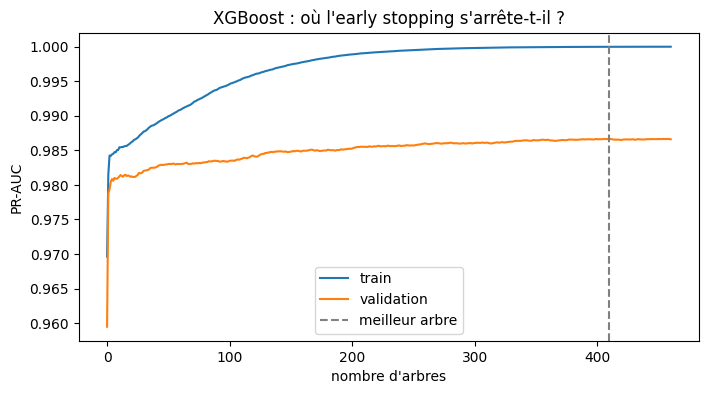

In [3]:
import matplotlib.pyplot as plt

historique = xgb.evals_result()
plt.figure(figsize=(8, 4))
plt.plot(historique["validation_0"]["aucpr"], label="train")
plt.plot(historique["validation_1"]["aucpr"], label="validation")
plt.axvline(xgb.best_iteration, color="gray", linestyle="--", label="meilleur arbre")
plt.xlabel("nombre d'arbres")
plt.ylabel("PR-AUC")
plt.title("XGBoost : où l'early stopping s'arrête-t-il ?")
plt.legend()
plt.show()

In [4]:
from aeroguard.evaluation import appliquer_seuil, metriques, taux_par_classe
from aeroguard.modeles import seuil_optimal

proba_val = xgb.predict_proba(X_val)[:, 1]
seuil, f1_seuil = seuil_optimal(y_val, proba_val)
print(f"Seuil optimal : {seuil}  (F1 macro {f1_seuil:.3f})")

lignes = {}
for nom, s in [("xgboost_gpu (0,5)", 0.5), (f"xgboost_gpu ({seuil})", seuil)]:
    pred = appliquer_seuil(proba_val, s)
    lignes[nom] = {**metriques(y_val, pred, proba_val), **taux_par_classe(y_val, pred)}

colonnes = ["f1_macro", "pr_auc", "rappel", "precision", "sains_reconnus", "fp", "fn"]
pd.DataFrame(lignes).T[colonnes].round(3)

/usr/local/lib/python3.13/dist-packages/xgboost/core.py:569: UserWarning: [14:27:02] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Seuil optimal : 0.81  (F1 macro 0.885)


,f1_macro,pr_auc,rappel,precision,sains_reconnus,fp,fn
"xgboost_gpu (0,5)",0.865,0.987,0.965,0.892,0.725,67.0,20.0
xgboost_gpu (0.81),0.885,0.987,0.906,0.951,0.889,27.0,54.0


In [5]:
from aeroguard.metier import bilan_flotte, resume_flotte

base = vols.loc[X_val.index, ["moteur", "cycle", "RUL"]].copy()
base["y"] = y_val.values
assert base["moteur"].nunique() == 11

resultats_metier = []
for nom, s in [("xgboost_gpu_s0.5", 0.5), (f"xgboost_gpu_s{seuil}", seuil)]:
    table = base.assign(alerte=appliquer_seuil(proba_val, s))
    bilan = bilan_flotte(table, "moteur", "cycle", "RUL", k=3)
    resultats_metier.append({"modele": nom, **resume_flotte(bilan)})
pd.DataFrame(resultats_metier).round(1)

,modele,moteurs,moteurs_detectes,avance_moyenne,avance_mediane,moteurs_avec_fausse_alarme,fausses_alarmes_total
0,xgboost_gpu_s0.5,11,11,47.8,45.0,7,20
1,xgboost_gpu_s0.81,11,11,42.5,39.0,2,2


In [6]:
import os
from aeroguard.evaluation import ajouter_au_leaderboard

cles = ["precision", "rappel", "f1", "f1_macro", "pr_auc", "fp", "fn"]
for nom, scores in lignes.items():
    ajouter_au_leaderboard(f"{DOSSIER}/results/leaderboard.csv", nom,
                           {k: scores[k] for k in cles})

for ligne in resultats_metier:
    nom = ligne.pop("modele") + "_k3"
    ajouter_au_leaderboard(f"{DOSSIER}/results/leaderboard_metier.csv", nom, ligne)

os.makedirs(f"{DOSSIER}/models", exist_ok=True)
xgb.save_model(f"{DOSSIER}/models/xgb_binaire_v3.json")
print("Modèle sauvegardé.")

pd.read_csv(f"{DOSSIER}/results/leaderboard.csv").sort_values("f1_macro", ascending=False)

Modèle sauvegardé.


,modele,f1_macro,pr_auc,rappel,precision,f1,fp,fn
2,logistique,0.886000,0.987000,0.932000,0.932000,0.932000,39.0,39.0
7,xgboost_gpu (0.81),0.885295,0.986677,0.906087,0.950730,0.927872,27.0,54.0
3,logistique_balanced,0.882083,0.986936,0.873043,0.974757,0.921101,NaN,NaN
6,"xgboost_gpu (0,5)",0.865020,0.986677,0.965217,0.892283,0.927318,67.0,20.0
4,random_forest,0.843745,0.984866,0.951304,0.882258,0.915481,73.0,28.0
1,copieur_knn,0.763000,0.903000,0.843000,0.866000,0.855000,75.0,90.0
5,isolation_forest_p95,0.612416,0.915238,0.485217,0.933110,0.638444,20.0,296.0
0,bete,0.412000,0.702000,1.000000,0.702000,0.825000,244.0,0.0
